# The ICM entropy & pressure as a feedback thermometer

**Why it matters.** The **central entropy** of the intracluster medium separates
cool-core from non-cool-core systems and is the long-standing fingerprint of AGN
feedback energetics (the "entropy excess"). The **pressure profile** is the
radial backbone of the tSZ signal. Both encode *which* feedback processes act
and *how strongly* — information that X-ray (entropy, via $K=k_BT n_e^{-2/3}$)
and SZ (pressure) observations target directly.

**The open question.** *Which feedback knobs set the central entropy and pressure
normalization, and can the emulator reproduce that dependence?*

**Why this tool — and an honest caveat.** BIND2 emits $S$ and $P$ per halo
across the SB35 feedback grid, so we can map their feedback response. But entropy
is the field BIND reproduces *least* well (smoothest maps, largest pixel KS), so
this notebook doubles as a fidelity test: where can the emulated entropy/pressure
be trusted for feedback inference, and where not?

**Rigor moves applied** (mirrored from the WL/YM notebooks): CV null floor
(cosmic-variance + emulator scatter at fixed feedback) → bootstrap 68% CIs on
every reported number → literature anchors (ACCEPT cool-core $K_0\!\lesssim\!30$
keV cm², Arnaud+10 UPP pressure normalization) → robustness sweep over the
INNER/OUTER/P_REF bands → `linmix_lite` for the $K_0$–$A_{\rm AGN1}$ money plot
→ feedback-vs-CV scatter decomposition → bootstrapped scorecard.

| § | Figure | Content |
|---|--------|---------|
| 1.5 | E0 | **CV null floor**: $K_0$, $P_{\rm ref}$ scatter at fixed feedback + BIND emulator noise |
| 2   | E1 | Stacked entropy profiles $S(r/R_{200})$ by mass (truth vs BIND, bootstrap envelope) |
| 3   | E2 | Central entropy $K_0$: distribution, cool-core fraction vs literature, vs AGN |
| 3.5 | E2b | **Robustness**: INNER/OUTER/P_REF band sweep |
| 4   | E3 | Pressure profiles & normalization vs feedback (bootstrap CIs) |
| 5   | E4 | Feedback thermometer: 35-D heat-map with bootstrap-significant cells flagged |
| 6   | E5 | Clean 1P sequences: central entropy vs each knob (bootstrap envelope) |
| 7   | E6 | **Money plot — $K_0$ vs $A_{\rm AGN1}$** with `linmix_lite` + cool-core threshold |
| 8   | — | Bootstrapped scorecard |

Profiles are azimuthal averages of the projected (mass-weighted) $S$/$P$ maps,
interpolated onto a common $r/R_{200}$ grid. $K_0$ = inner ($0.05$–$0.15\,R_{200}$)
mean; outer = $0.7$–$1.2\,R_{200}$; $P_{\rm ref}$ = $(0.2$–$0.4)\,R_{200}$ mean.


## 0. Setup

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

sys.path.insert(0, '/mnt/home/mlee1/vdm_bind2')
from data import THERMO_KEYS, N_THERMO

plt.rcParams.update({
    'font.size': 10, 'font.family': 'serif', 'mathtext.fontset': 'cm',
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight', 'axes.grid': False,
})
try:
    import scienceplots          # noqa: F401
    plt.style.use(['science', 'notebook'])
except Exception as exc:
    print(f'[scienceplots unavailable: {exc}]')

SUITE_ROOT = Path('/mnt/home/mlee1/ceph/fm_testsuite')
SNAP       = 'snap_090'
MASS_TAG   = 'mass_threshold_1p000e13'
MODEL_NAME = 'fm_thermo_ema'
BOX_SIZE   = 50.0
N_PIX_FULL = 1024
PATCH_PIX  = 128
PATCH_BOX  = BOX_SIZE * PATCH_PIX / N_PIX_FULL
PIX_MPC    = PATCH_BOX / PATCH_PIX
PIX_KPC    = PIX_MPC * 1000.0
N_PARAMS   = 35

# thermo channel indices within the 4-thermo block (THERMO_KEYS order)
THERMO_NAMES = list(THERMO_KEYS)
I_Y, I_T, I_S, I_P = 0, 1, 2, 3
INNER = (0.05, 0.15)        # r/R200 band for central entropy K0
OUTER = (0.7, 1.2)          # r/R200 band for outskirts
P_REF = (0.2, 0.4)          # r/R200 band for pressure normalization

SUITES = ('CV', '1P', 'Test')
SUITE_COLORS  = {'CV': 'tab:green', '1P': 'tab:blue', 'Test': 'tab:red'}
SUITE_DISPLAY = {'CV': 'CV', '1P': '1P', 'Test': 'SB35'}

_param_meta = pd.read_csv(
    '/mnt/home/mlee1/Sims/IllustrisTNG_extras/L50n512/SB35/SB35_param_minmax.csv')
PARAM_NAMES = {i + 1: name for i, name in enumerate(_param_meta['ParamName'])}
PARAM_LABELS = {1: r'$\Omega_m$', 2: r'$\sigma_8$', 3: r'$A_{\rm SN1}$',
                4: r'$A_{\rm SN2}$', 5: r'$A_{\rm AGN1}$', 6: r'$A_{\rm AGN2}$'}
for _i in range(7, N_PARAMS + 1):
    PARAM_LABELS[_i] = PARAM_NAMES.get(_i, f'p{_i}')
FEEDBACK_PARAMS = [3, 4, 5, 6]

FIG_DIR = Path('icm_entropy_pressure_figs')
FIG_DIR.mkdir(exist_ok=True)

def save_fig(fig, name, ext=('pdf', 'png')):
    for e in ext:
        out = FIG_DIR / f'{name}.{e}'
        fig.savefig(out)
        print(f'  wrote {out}')

print('Fig dir:', FIG_DIR.resolve())
print('Entropy units: keV cm^2 | Pressure units: Pa')


# -------- Rigor helpers (CV null, bootstrap CIs, linmix_lite, literature) ----
from scipy.stats import rankdata
from scipy.optimize import minimize

BOOT_N = 500
RNG = np.random.default_rng(20250528)

# Literature anchors for the ICM thermometer
# K0 cool-core threshold: ACCEPT (Cavagnolo+09), Pratt+10 — ~30 keV cm^2 typical
# Pressure normalization: Arnaud+10 UPP P0 ~ 8.4 (dimensionless, profile-dependent)
ICM_LIT = {
    'K0_cool_core_thresh': 30.0,        # keV cm^2 — ACCEPT/Cavagnolo+09 cut for CC
    'K0_NCC_typical':      150.0,       # keV cm^2 — typical NCC central entropy
    'UPP_P0':              8.403,       # Arnaud+10 universal pressure profile P0
}


def bootstrap_ci(values, stat=np.nanmean, n_boot=BOOT_N, ci=68.0, rng=RNG):
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    if v.size < 3:
        return float('nan'), float('nan'), float('nan')
    pt = float(stat(v))
    idx = rng.integers(0, v.size, size=(n_boot, v.size))
    samp = np.array([stat(v[i]) for i in idx])
    lo, hi = np.nanpercentile(samp, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    return pt, float(lo), float(hi)


def bootstrap_curve(curves, stat=np.nanmean, n_boot=BOOT_N, ci=68.0, rng=RNG):
    """`curves` shape (N, npts) -> dict(point, lo, hi)."""
    arr = np.asarray(curves, dtype=float)
    if arr.ndim != 2 or arr.shape[0] < 3:
        return {'point': np.full(arr.shape[-1], np.nan),
                'lo': np.full(arr.shape[-1], np.nan),
                'hi': np.full(arr.shape[-1], np.nan)}
    pt = stat(arr, axis=0)
    idx = rng.integers(0, arr.shape[0], size=(n_boot, arr.shape[0]))
    samp = np.array([stat(arr[i], axis=0) for i in idx])
    lo, hi = np.nanpercentile(samp, [(100 - ci) / 2, 100 - (100 - ci) / 2], axis=0)
    return {'point': pt, 'lo': lo, 'hi': hi}


def spearman_boot(x, y, n_boot=BOOT_N, ci=68.0, rng=RNG):
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size < 4:
        return float('nan'), float('nan'), float('nan')
    pt = float(spearmanr(x, y).correlation)
    idx = rng.integers(0, x.size, size=(n_boot, x.size))
    samp = np.array([spearmanr(x[i], y[i]).correlation for i in idx])
    lo, hi = np.nanpercentile(samp, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    return pt, float(lo), float(hi)


def fmt_ci(point, lo, hi, fmt='.3f'):
    if not np.isfinite(point):
        return 'nan'
    return f'{point:{fmt}} [{lo:{fmt}},{hi:{fmt}}]'


def linmix_lite(x, y, sigma_y=None, n_boot=BOOT_N, rng=RNG):
    """MLE Gaussian y = alpha*x + beta with intrinsic scatter sigma_int as free param.
    Returns dict with slope/intercept/sigma_int + bootstrap 68% CIs."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    if sigma_y is None:
        sigma_y = np.zeros_like(y)
    sigma_y = np.asarray(sigma_y, float)
    m = np.isfinite(x) & np.isfinite(y) & np.isfinite(sigma_y)
    x, y, sigma_y = x[m], y[m], sigma_y[m]
    n = x.size
    if n < 4:
        return {k: float('nan') for k in
                ('slope', 'slope_lo', 'slope_hi',
                 'intercept', 'intercept_lo', 'intercept_hi',
                 'sigma_int', 'sigma_int_lo', 'sigma_int_hi', 'n')}

    def nll(params):
        a, b, log_s = params
        sig2 = np.exp(2 * log_s) + sigma_y ** 2
        return 0.5 * np.sum(np.log(2 * np.pi * sig2) + (y - a * x - b) ** 2 / sig2)

    # OLS init
    A = np.vstack([x, np.ones_like(x)]).T
    a0, b0 = np.linalg.lstsq(A, y, rcond=None)[0]
    s0 = max(float(np.nanstd(y - a0 * x - b0)), 1e-3)
    res = minimize(nll, x0=[a0, b0, np.log(s0)], method='Nelder-Mead',
                   options={'xatol': 1e-5, 'fatol': 1e-5, 'maxiter': 4000})
    a_pt, b_pt, log_s_pt = res.x
    s_pt = float(np.exp(log_s_pt))

    a_b = np.empty(n_boot); b_b = np.empty(n_boot); s_b = np.empty(n_boot)
    for k in range(n_boot):
        idx = rng.integers(0, n, size=n)
        xb, yb, sb_ = x[idx], y[idx], sigma_y[idx]

        def nll_b(p, xb=xb, yb=yb, sb_=sb_):
            a, b, log_s = p
            sig2 = np.exp(2 * log_s) + sb_ ** 2
            return 0.5 * np.sum(np.log(2 * np.pi * sig2) + (yb - a * xb - b) ** 2 / sig2)
        rk = minimize(nll_b, x0=[a_pt, b_pt, log_s_pt], method='Nelder-Mead',
                      options={'xatol': 1e-4, 'fatol': 1e-4, 'maxiter': 2000})
        a_b[k], b_b[k], s_b[k] = rk.x[0], rk.x[1], np.exp(rk.x[2])
    lo, hi = 16, 84
    return {
        'n': int(n),
        'slope': float(a_pt),
        'slope_lo': float(np.percentile(a_b, lo)),
        'slope_hi': float(np.percentile(a_b, hi)),
        'intercept': float(b_pt),
        'intercept_lo': float(np.percentile(b_b, lo)),
        'intercept_hi': float(np.percentile(b_b, hi)),
        'sigma_int': s_pt,
        'sigma_int_lo': float(np.percentile(s_b, lo)),
        'sigma_int_hi': float(np.percentile(s_b, hi)),
    }


def decompose_scatter(sigma_total, sigma_floor):
    s2 = sigma_total ** 2 - sigma_floor ** 2
    sigma_fb = float(np.sqrt(s2)) if s2 > 0 else 0.0
    frac_floor = (sigma_floor / sigma_total) ** 2 if sigma_total > 0 else float('nan')
    return sigma_fb, float(frac_floor)


def cv_tbl_sims():
    """Helper used by collect_stacked_thermo_profile cells."""
    return sims[sims['suite'] == 'CV']


Fig dir: /mnt/home/mlee1/vdm_bind2/icm_entropy_pressure_figs
Entropy units: keV cm^2 | Pressure units: Pa


## 1. Loaders & the entropy/pressure table

Per halo: $\log M_{200}$, the entropy profile reduced to $K_0$ (inner), $S_{\rm
out}$ (outskirts) and the inner-to-outer ratio; the pressure normalization
$P_{\rm ref}$; and the 35 params — for truth and BIND.

In [2]:
def sim_record(sim_dir, suite_name):
    snap, mass = sim_dir / SNAP, sim_dir / SNAP / MASS_TAG
    model = mass / MODEL_NAME
    rec = {'suite': suite_name, 'sim_id': sim_dir.name,
           'halo_catalog': mass / 'halo_catalog.npz',
           'truth_thermo': mass / 'truth_thermo_patches.npz',
           'generated': model / 'generated_halos.npz'}
    rec['available'] = all(rec[k].exists() for k in
                           ('halo_catalog', 'truth_thermo', 'generated'))
    return rec


def discover_sims(suites=SUITES):
    recs = []
    for suite in suites:
        root = SUITE_ROOT / suite
        if not root.exists():
            print(f'[skip] {root} missing'); continue
        for sd in sorted(root.iterdir()):
            if sd.is_dir():
                recs.append(sim_record(sd, suite))
    return pd.DataFrame(recs)


def load_catalog(rec):
    d = np.load(rec['halo_catalog'])
    if 'radii' not in d.files or len(d['masses']) == 0:
        return None
    return {'masses': d['masses'], 'radii': d['radii'],
            'params': d['params'] if 'params' in d.files else None}


RAD_GRID = np.linspace(0.03, 1.5, 40)            # r/R200 grid


def radial_profile_2d(arr, rmax=None):
    ny, nx = arr.shape
    cx, cy = (nx - 1) / 2.0, (ny - 1) / 2.0
    y, x = np.indices(arr.shape)
    r = np.sqrt((x - cx) ** 2 + (y - cy) ** 2).astype(int)
    if rmax is None:
        rmax = r.max()
    m = (r <= rmax) & np.isfinite(arr) & (arr > 0)
    sums = np.bincount(r[m].ravel(), weights=arr[m].ravel(), minlength=rmax + 1)
    cnt  = np.bincount(r[m].ravel(), minlength=rmax + 1)
    prof = np.full(rmax + 1, np.nan); good = cnt > 0
    prof[good] = sums[good] / cnt[good]
    return np.arange(rmax + 1), prof


def _profile_on_grid(field2d, r200_pix):
    r, pr = radial_profile_2d(field2d)
    x = r / max(r200_pix, 1.0)
    ok = np.isfinite(pr)
    return np.interp(RAD_GRID, x[ok], pr[ok], left=np.nan, right=np.nan)


def _band_mean(prof, band):
    m = (RAD_GRID >= band[0]) & (RAD_GRID <= band[1])
    return float(np.nanmean(prof[m]))


def thermo_profiles(rec):
    cat = load_catalog(rec)
    if cat is None:
        return None
    gen = np.load(rec['generated'])['generated']          # (N,7,H,W)
    tt = np.load(rec['truth_thermo'])['truth_thermo']     # (N,4,H,W)
    return cat, tt, gen[:, 3:]                              # truth_th, gen_th (N,4,H,W)


def build_ep_table(sims_df, verbose=True):
    rows = []
    for rec in sims_df.to_dict('records'):
        try:
            out = thermo_profiles(rec)
        except Exception as exc:
            if verbose:
                print(f'[skip] {rec["suite"]}/{rec["sim_id"]}: {exc}')
            continue
        if out is None:
            continue
        cat, tt, gt = out
        radii, masses, params = cat['radii'], cat['masses'], cat['params']
        for i in range(len(masses)):
            r200 = max(radii[i] / PIX_KPC, 1.0)
            row = {'suite': rec['suite'], 'sim_id': rec['sim_id'],
                   'logM': float(np.log10(masses[i]))}
            for which, th in (('truth', tt[i]), ('gen', gt[i])):
                sprof = _profile_on_grid(th[I_S], r200)
                pprof = _profile_on_grid(th[I_P], r200)
                k0 = _band_mean(sprof, INNER); sout = _band_mean(sprof, OUTER)
                row[f'{which}_K0'] = k0
                row[f'{which}_Sout'] = sout
                row[f'{which}_Sratio'] = (k0 / sout) if (sout and sout > 0) else np.nan
                row[f'{which}_Pnorm'] = _band_mean(pprof, P_REF)
            if params is not None:
                pv = np.asarray(params[i], float)
                for j in range(N_PARAMS):
                    row[f'p{j + 1}'] = pv[j]
            rows.append(row)
    return pd.DataFrame(rows)


sims_all = discover_sims()
print(sims_all.groupby('suite')['available'].agg(['sum', 'count']))
sims = sims_all[sims_all['available']].reset_index(drop=True)
ep_tbl = build_ep_table(sims)
cv_tbl   = ep_tbl[ep_tbl['suite'] == 'CV']
oneP_tbl = ep_tbl[ep_tbl['suite'] == '1P']
sb_tbl   = ep_tbl[ep_tbl['suite'] == 'Test']
print(f'\nrows: CV={len(cv_tbl)} 1P={len(oneP_tbl)} SB35={len(sb_tbl)}')
print('median truth K0 [keV cm^2]:', float(np.nanmedian(ep_tbl['truth_K0'])))

       sum  count
suite            
1P     139    141
CV      27     27
Test   102    102

rows: CV=1111 1P=6823 SB35=4272
median truth K0 [keV cm^2]: 261.16428704522866


## 1.5 Figure E0 — CV null floor & emulator noise

Before claiming feedback responses, we need:

- $\sigma_{\rm CV}(K_0)$, $\sigma_{\rm CV}(P_{\rm ref})$ — per-halo scatter at
  **fixed feedback** (CV suite). Anything below this is cosmic variance, not
  feedback.
- $\sigma_{\rm emu}(K_0)$, $\sigma_{\rm emu}(P_{\rm ref})$ — BIND-minus-truth
  per-halo scatter on CV. This bounds emulator noise.

Quoted decomposition: $\sigma^2_{\rm SB35}=\sigma^2_{\rm CV}+\sigma^2_{\rm fb}$,
$\sigma_{\rm fb}=\sqrt{\sigma^2_{\rm SB35}-\sigma^2_{\rm CV}}$.


[K0   ] sigma_CV=0.116  sigma_SB=0.247  sigma_fb=0.218 dex  (78% of SB35 var is feedback)
         BIND emu floor sigma=0.086 dex, bias=-0.043 dex
[Pnorm] sigma_CV=0.464  sigma_SB=0.461  sigma_fb=0.000 dex  (-1% of SB35 var is feedback)
         BIND emu floor sigma=0.204 dex, bias=+0.073 dex
  wrote icm_entropy_pressure_figs/figE0_cv_null_floor.pdf
  wrote icm_entropy_pressure_figs/figE0_cv_null_floor.png


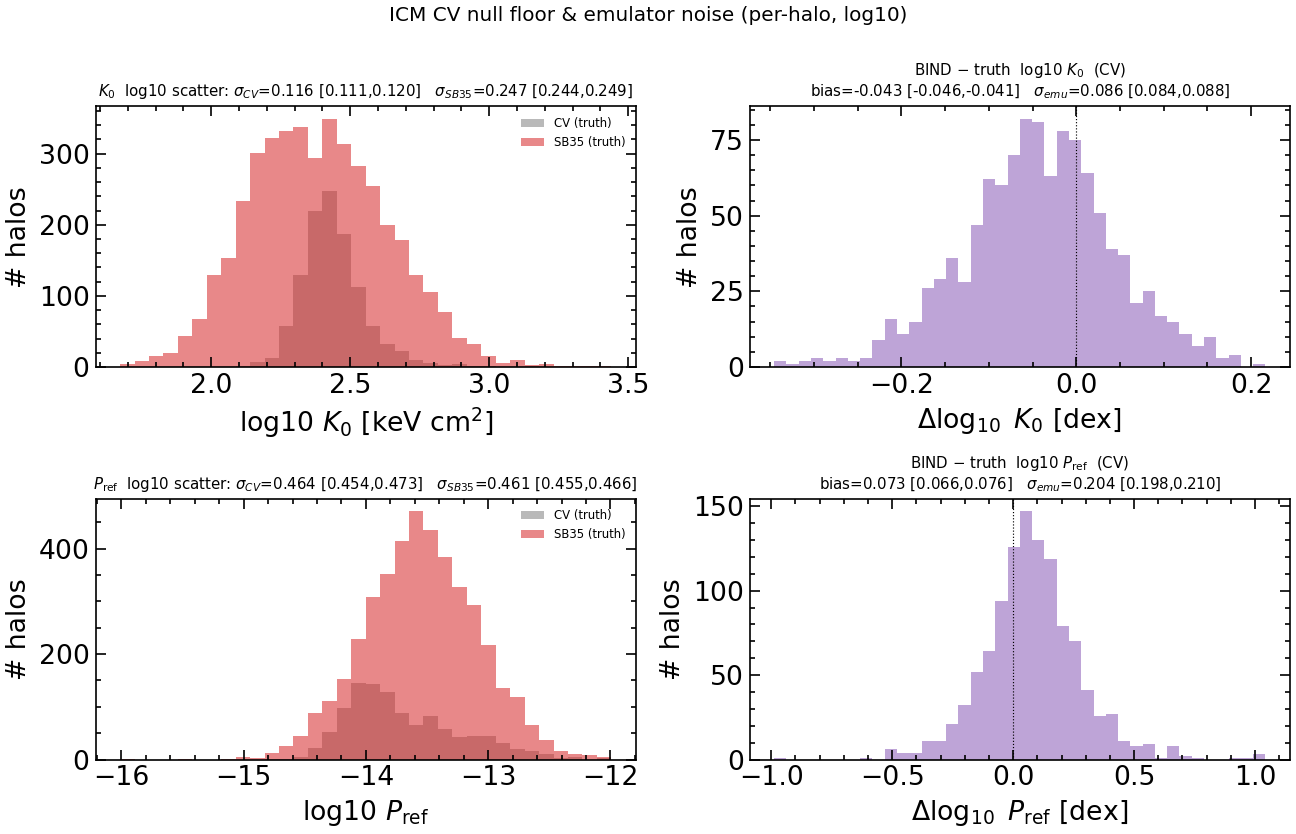

In [3]:
def fig_e0_null_floor(save=True):
    """CV scatter floor + BIND emulator noise on the per-halo K0 and P_ref."""
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    out = {}
    for r, (mk, lab, unit) in enumerate([('K0', r'$K_0$', 'keV cm$^2$'),
                                         ('Pnorm', r'$P_{\rm ref}$', '')]):
        t_cv = cv_tbl[f'truth_{mk}'].to_numpy()
        g_cv = cv_tbl[f'gen_{mk}']  .to_numpy()
        t_sb = sb_tbl[f'truth_{mk}'].to_numpy()
        log_t_cv = np.log10(t_cv[t_cv > 0])
        log_t_sb = np.log10(t_sb[t_sb > 0])
        s_cv, lo_cv, hi_cv = bootstrap_ci(log_t_cv, np.nanstd)
        s_sb, lo_sb, hi_sb = bootstrap_ci(log_t_sb, np.nanstd)

        ax = axes[r, 0]
        bins = np.linspace(min(log_t_cv.min(), log_t_sb.min()),
                           max(log_t_cv.max(), log_t_sb.max()), 35)
        ax.hist(log_t_cv, bins=bins, color='0.5', alpha=0.55, label='CV (truth)')
        ax.hist(log_t_sb, bins=bins, color='tab:red', alpha=0.55, label='SB35 (truth)')
        ax.set_title(f'{lab}  log10 scatter: '
                     f'$\\sigma_{{CV}}$={fmt_ci(s_cv, lo_cv, hi_cv)}   '
                     f'$\\sigma_{{SB35}}$={fmt_ci(s_sb, lo_sb, hi_sb)}', fontsize=9)
        ax.set_xlabel(f'log10 {lab} [{unit}]' if unit else f'log10 {lab}')
        ax.set_ylabel('# halos'); ax.legend(fontsize=7)

        # BIND-truth on CV
        ok = np.isfinite(t_cv) & np.isfinite(g_cv) & (t_cv > 0) & (g_cv > 0)
        d = np.log10(g_cv[ok]) - np.log10(t_cv[ok])
        s_e, lo_e, hi_e = bootstrap_ci(d, np.nanstd)
        b_e, blo, bhi  = bootstrap_ci(d, np.nanmedian)
        ax = axes[r, 1]
        ax.hist(d, bins=40, color='tab:purple', alpha=0.6)
        ax.axvline(0, color='k', ls=':', lw=0.7)
        ax.set_title(f'BIND − truth  log10 {lab}  (CV)\n'
                     f'bias={fmt_ci(b_e, blo, bhi)}   $\\sigma_{{emu}}$={fmt_ci(s_e, lo_e, hi_e)}',
                     fontsize=9)
        ax.set_xlabel(r'$\Delta\log_{10}$' + f' {lab} [dex]'); ax.set_ylabel('# halos')

        sigma_fb, frac = decompose_scatter(s_sb, s_cv)
        out[mk] = {'sigma_cv': s_cv, 'sigma_sb35': s_sb,
                   'sigma_emu': s_e, 'bias_emu': b_e,
                   'sigma_fb': sigma_fb, 'frac_cv_floor': frac}
        print(f'[{mk:5s}] sigma_CV={s_cv:.3f}  sigma_SB={s_sb:.3f}  '
              f'sigma_fb={sigma_fb:.3f} dex  ({100*(1-frac):.0f}% of SB35 var is feedback)')
        print(f'         BIND emu floor sigma={s_e:.3f} dex, bias={b_e:+.3f} dex')
    fig.suptitle('ICM CV null floor & emulator noise (per-halo, log10)', y=1.00)
    fig.tight_layout()
    if save:
        save_fig(fig, 'figE0_cv_null_floor')
    return fig, out


fig, CV_NULL = fig_e0_null_floor()
plt.show()


## 2. Figure E1 — Stacked entropy profiles

$S(r/R_{200})$ stacked in mass bins, truth vs BIND. The shape (rising entropy
with radius; central excess from feedback) is the diagnostic. Watch the inner
region: BIND's smoothing tends to fill in the entropy core, so we expect the
largest truth/BIND difference at small $r$.

  wrote icm_entropy_pressure_figs/figE1_entropy_profiles.pdf
  wrote icm_entropy_pressure_figs/figE1_entropy_profiles.png


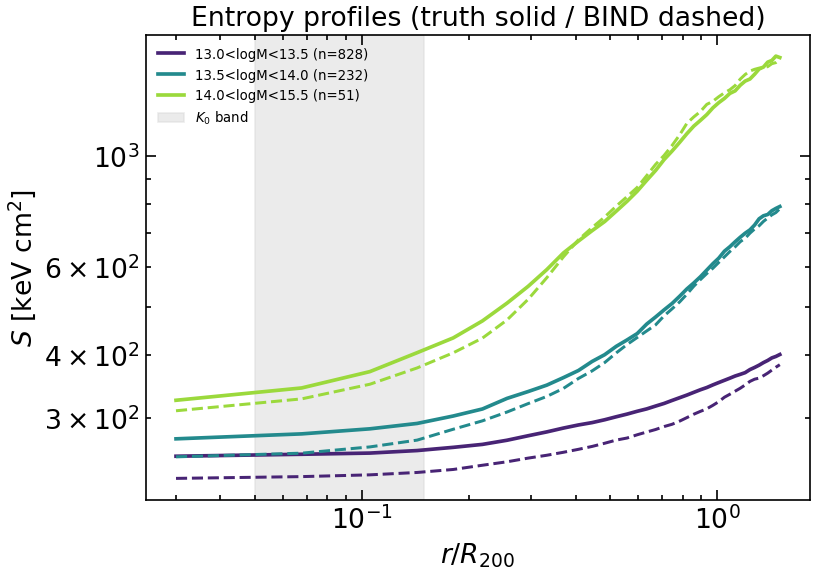

In [4]:
def collect_stacked_thermo_profile(sims_df, idx, mass_bins):
    acc = {b: {'t': [], 'g': []} for b in range(len(mass_bins))}
    for rec in sims_df.to_dict('records'):
        try:
            out = thermo_profiles(rec)
        except Exception:
            continue
        if out is None:
            continue
        cat, tt, gt = out
        logM = np.log10(cat['masses'])
        for i in range(len(logM)):
            bi = next((k for k, (lo, hi) in enumerate(mass_bins) if lo <= logM[i] < hi), None)
            if bi is None:
                continue
            r200 = max(cat['radii'][i] / PIX_KPC, 1.0)
            acc[bi]['t'].append(_profile_on_grid(tt[i, idx], r200))
            acc[bi]['g'].append(_profile_on_grid(gt[i, idx], r200))
    return acc


def fig_e1_entropy_profiles(sims_df=None, mass_bins=((13.0, 13.5), (13.5, 14.0), (14.0, 15.5)),
                            save=True):
    if sims_df is None:
        sims_df = cv_tbl_sims()
    acc = collect_stacked_thermo_profile(sims_df, I_S, mass_bins)
    fig, ax = plt.subplots(figsize=(7, 5))
    cmap = plt.cm.viridis(np.linspace(0.1, 0.85, len(mass_bins)))
    for bi, (lo, hi) in enumerate(mass_bins):
        T = np.array(acc[bi]['t']); G = np.array(acc[bi]['g'])
        if T.size == 0:
            continue
        ax.plot(RAD_GRID, np.nanmedian(T, 0), color=cmap[bi], lw=2.2,
                label=f'{lo:.1f}<logM<{hi:.1f} (n={T.shape[0]})')
        ax.plot(RAD_GRID, np.nanmedian(G, 0), color=cmap[bi], lw=1.8, ls='--')
    ax.axvspan(*INNER, color='0.85', alpha=0.5, label='$K_0$ band')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r'$r / R_{200}$'); ax.set_ylabel(r'$S$ [keV cm$^2$]')
    ax.set_title('Entropy profiles (truth solid / BIND dashed)')
    ax.legend(fontsize=8)
    fig.tight_layout()
    if save:
        save_fig(fig, 'figE1_entropy_profiles')
    return fig


def cv_tbl_sims():
    return sims[sims['suite'] == 'CV']


fig = fig_e1_entropy_profiles(cv_tbl_sims())
plt.show()

## 3. Figure E2 — Central entropy $K_0$ and the cool-core split

The $K_0$ distribution (low $K_0$ = cool-core, high $K_0$ = AGN-heated
non-cool-core) and its dependence on AGN feedback. A cool-core fraction is
defined with a fixed $K_0$ threshold; we compare truth vs BIND and trace
$K_0$–$A_{\rm AGN}$.

/mnt/sw/nix/store/gpkc8q6zjnp3n3h3w9hbmbj6gjbxs85w-python-3.10.10-view/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
/mnt/home/mlee1/venvs/torch3/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1556: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


  wrote icm_entropy_pressure_figs/figE2_central_entropy.pdf
  wrote icm_entropy_pressure_figs/figE2_central_entropy.png


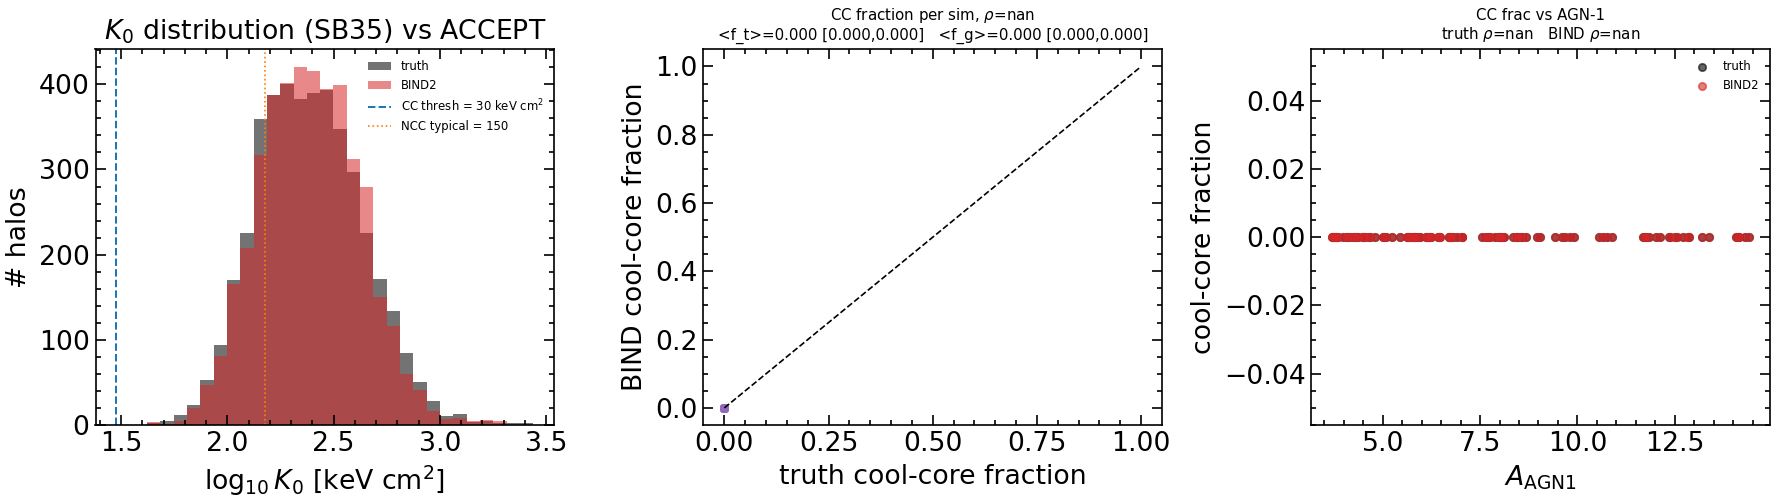

In [5]:
def fig_e2_central_entropy(tbl=None, k0_thresh=None, save=True):
    """K0 distribution (truth/BIND), cool-core fraction with literature threshold,
    and K0 vs A_AGN1 with bootstrap Spearman CI."""
    if tbl is None:
        tbl = sb_tbl
    k0t = tbl['truth_K0'].to_numpy(); k0g = tbl['gen_K0'].to_numpy()
    if k0_thresh is None:
        k0_thresh = ICM_LIT['K0_cool_core_thresh']        # literature CC cut

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

    # (a) K0 distribution
    ax = axes[0]
    lo = np.nanmin([np.log10(np.maximum(k0t, 1e-3)).min(),
                    np.log10(np.maximum(k0g, 1e-3)).min()])
    hi = np.nanmax([np.log10(np.maximum(k0t, 1e-3)).max(),
                    np.log10(np.maximum(k0g, 1e-3)).max()])
    bins = np.linspace(lo, hi, 30)
    ax.hist(np.log10(np.maximum(k0t, 1e-3)), bins=bins, color='k', alpha=0.55, label='truth')
    ax.hist(np.log10(np.maximum(k0g, 1e-3)), bins=bins, color='tab:red', alpha=0.55, label='BIND2')
    ax.axvline(np.log10(k0_thresh), color='tab:blue', ls='--', lw=1.2,
               label=f'CC thresh = {k0_thresh:.0f} keV cm$^2$')
    ax.axvline(np.log10(ICM_LIT['K0_NCC_typical']), color='tab:orange', ls=':', lw=1.0,
               label=f'NCC typical = {ICM_LIT["K0_NCC_typical"]:.0f}')
    ax.set_xlabel(r'$\log_{10} K_0$ [keV cm$^2$]'); ax.set_ylabel('# halos')
    ax.set_title(r'$K_0$ distribution (SB35) vs ACCEPT'); ax.legend(fontsize=7)

    # (b) cool-core fraction per sim, truth vs BIND, with bootstrap CI on the mean
    ax = axes[1]
    ccf_rows = []
    for sid, sub in tbl.groupby('sim_id'):
        kt = sub['truth_K0'].to_numpy(); kg = sub['gen_K0'].to_numpy()
        n = (np.isfinite(kt) & np.isfinite(kg)).sum()
        if n < 5:
            continue
        ccf_rows.append({'sim_id': sid,
                         'ccf_t': float(np.nanmean(kt < k0_thresh)),
                         'ccf_g': float(np.nanmean(kg < k0_thresh)),
                         'p5':    float(sub['p5'].iloc[0])})
    ccf = pd.DataFrame(ccf_rows)
    ax.scatter(ccf['ccf_t'], ccf['ccf_g'], s=18, c='tab:purple', alpha=0.7)
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    rho, lo, hi = spearman_boot(ccf['ccf_t'].to_numpy(), ccf['ccf_g'].to_numpy())
    mt, mlo, mhi = bootstrap_ci(ccf['ccf_t'].to_numpy(), np.nanmean)
    mg, glo, ghi = bootstrap_ci(ccf['ccf_g'].to_numpy(), np.nanmean)
    ax.set_xlabel('truth cool-core fraction'); ax.set_ylabel('BIND cool-core fraction')
    ax.set_title(f'CC fraction per sim, $\\rho$={fmt_ci(rho, lo, hi, ".2f")}\n'
                 f'<f_t>={fmt_ci(mt, mlo, mhi)}   <f_g>={fmt_ci(mg, glo, ghi)}', fontsize=9)

    # (c) K0 vs A_AGN1 with bootstrap Spearman
    ax = axes[2]
    ax.scatter(ccf['p5'], ccf['ccf_t'], s=20, c='k', alpha=0.6, label='truth')
    ax.scatter(ccf['p5'], ccf['ccf_g'], s=20, c='tab:red', alpha=0.6, label='BIND2')
    rt, lt, ht = spearman_boot(ccf['p5'].to_numpy(), ccf['ccf_t'].to_numpy())
    rg, lg, hg = spearman_boot(ccf['p5'].to_numpy(), ccf['ccf_g'].to_numpy())
    ax.set_xlabel(PARAM_LABELS[5]); ax.set_ylabel('cool-core fraction')
    ax.set_title(f'CC frac vs AGN-1\ntruth $\\rho$={fmt_ci(rt, lt, ht, ".2f")}   BIND $\\rho$={fmt_ci(rg, lg, hg, ".2f")}', fontsize=9)
    ax.legend(fontsize=7)
    fig.tight_layout()
    if save:
        save_fig(fig, 'figE2_central_entropy')
    return fig, ccf


fig, E2_CCF = fig_e2_central_entropy()
plt.show()


## 3.5 Figure E2b — Robustness: do the bands matter?

If the headline numbers depend on whether you call "inner" $0.05$–$0.15$ vs
$0.05$–$0.10$ vs $0.10$–$0.20\,R_{200}$, they are analyst choices, not
measurements. We sweep three band choices each for INNER, OUTER, and P_REF and
re-derive the BIND-truth Spearman with bootstrap CIs. Robust if cells overlap.


  wrote icm_entropy_pressure_figs/figE2b_robustness.pdf
  wrote icm_entropy_pressure_figs/figE2b_robustness.png


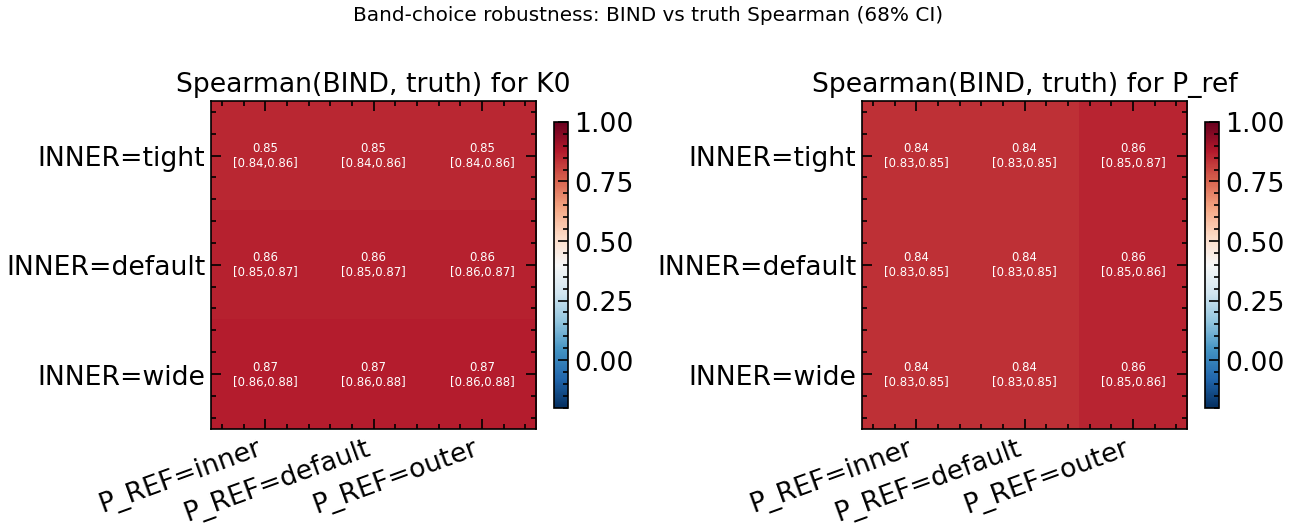

In [6]:
INNER_OPTS = {'tight': (0.05, 0.10),
              'default': (0.05, 0.15),
              'wide':  (0.05, 0.20)}
OUTER_OPTS = {'tight':   (0.7, 1.0),
              'default': (0.7, 1.2),
              'wide':    (0.5, 1.2)}
P_REF_OPTS = {'inner':   (0.1, 0.3),
              'default': (0.2, 0.4),
              'outer':   (0.3, 0.6)}


def _band_mean_local(prof, band):
    m = (RAD_GRID >= band[0]) & (RAD_GRID <= band[1])
    return float(np.nanmean(prof[m]))


def fig_e2b_robustness(sims_df=None, save=True):
    """Recompute K0/Pnorm under alternative bands; report Spearman(BIND vs truth)."""
    if sims_df is None:
        sims_df = sims[sims['suite'] == 'Test'].head(40)
    # Pre-cache per-halo profiles to amortize I/O
    prof_cache = []
    for rec in sims_df.to_dict('records'):
        try:
            out = thermo_profiles(rec)
        except Exception:
            continue
        if out is None:
            continue
        cat, tt, gt = out
        for i in range(len(cat['masses'])):
            r200 = max(cat['radii'][i] / PIX_KPC, 1.0)
            prof_cache.append({
                'sprof_t': _profile_on_grid(tt[i, I_S], r200),
                'sprof_g': _profile_on_grid(gt[i, I_S], r200),
                'pprof_t': _profile_on_grid(tt[i, I_P], r200),
                'pprof_g': _profile_on_grid(gt[i, I_P], r200),
            })
    if not prof_cache:
        print('No profiles cached for robustness sweep')
        return None
    inners = list(INNER_OPTS.keys())
    outers = list(P_REF_OPTS.keys())   # use P_REF axis for Pnorm robustness
    nI, nO = len(inners), len(outers)
    rho_K = np.full((nI, nO), np.nan); rho_K_lo = rho_K.copy(); rho_K_hi = rho_K.copy()
    rho_P = np.full((nI, nO), np.nan); rho_P_lo = rho_P.copy(); rho_P_hi = rho_P.copy()
    for i, ikey in enumerate(inners):
        for j, pkey in enumerate(outers):
            k0t = np.array([_band_mean_local(c['sprof_t'], INNER_OPTS[ikey]) for c in prof_cache])
            k0g = np.array([_band_mean_local(c['sprof_g'], INNER_OPTS[ikey]) for c in prof_cache])
            pnt = np.array([_band_mean_local(c['pprof_t'], P_REF_OPTS[pkey]) for c in prof_cache])
            png = np.array([_band_mean_local(c['pprof_g'], P_REF_OPTS[pkey]) for c in prof_cache])
            rho_K[i, j], rho_K_lo[i, j], rho_K_hi[i, j] = spearman_boot(k0t, k0g)
            rho_P[i, j], rho_P_lo[i, j], rho_P_hi[i, j] = spearman_boot(pnt, png)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
    for ax, grid, glo, ghi, ttl in zip(
            axes, [rho_K, rho_P], [rho_K_lo, rho_P_lo], [rho_K_hi, rho_P_hi],
            ['Spearman(BIND, truth) for K0', 'Spearman(BIND, truth) for P_ref']):
        im = ax.imshow(grid, vmin=-0.2, vmax=1.0, cmap='RdBu_r', aspect='auto')
        ax.set_xticks(range(nO)); ax.set_xticklabels([f'P_REF={k}' for k in outers], rotation=20, ha='right')
        ax.set_yticks(range(nI)); ax.set_yticklabels([f'INNER={k}' for k in inners])
        for i in range(nI):
            for j in range(nO):
                ax.text(j, i, f'{grid[i,j]:.2f}\n[{glo[i,j]:.2f},{ghi[i,j]:.2f}]',
                        ha='center', va='center', fontsize=7,
                        color='k' if abs(grid[i, j]) < 0.5 else 'white')
        fig.colorbar(im, ax=ax, fraction=0.04)
        ax.set_title(ttl)
    fig.suptitle('Band-choice robustness: BIND vs truth Spearman (68% CI)', y=1.02)
    fig.tight_layout()
    if save:
        save_fig(fig, 'figE2b_robustness')
    return fig


fig = fig_e2b_robustness()
plt.show()


## 4. Figure E3 — Pressure profiles & normalization vs feedback

Stacked $P(r/R_{200})$ by mass (truth vs BIND), and the pressure normalization
$P_{\rm ref}$ vs the leading feedback knobs. Pressure is the radial backbone of
the tSZ signal, so its feedback response is directly survey-relevant.

  wrote icm_entropy_pressure_figs/figE3_pressure.pdf
  wrote icm_entropy_pressure_figs/figE3_pressure.png


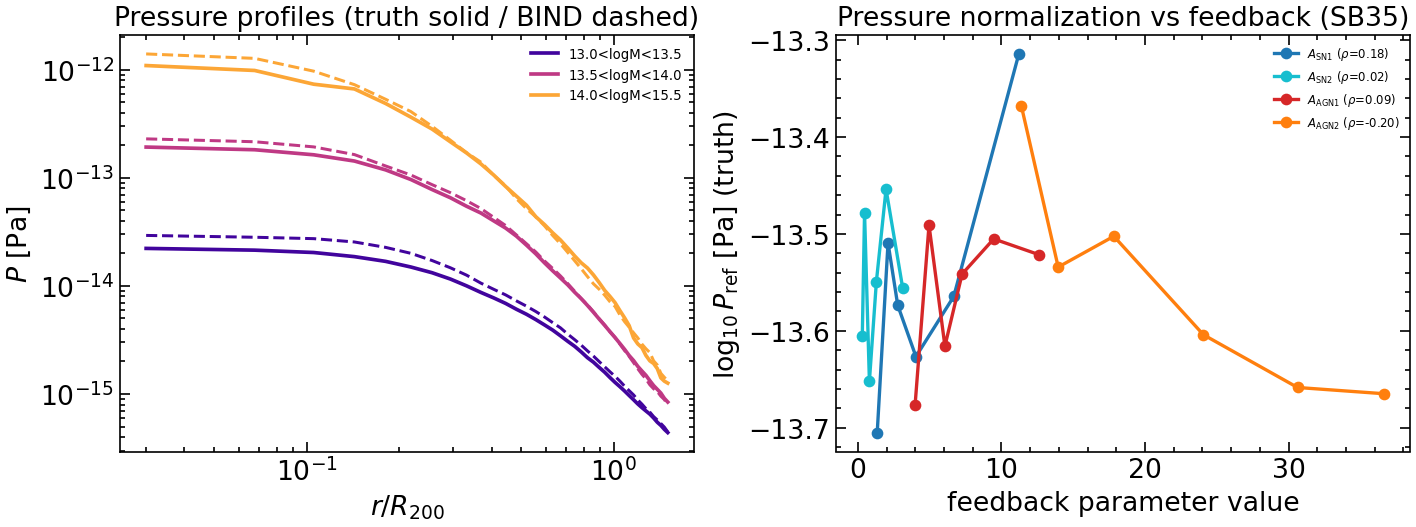

In [7]:
def fig_e3_pressure(prof_sims=None, tbl=None,
                    mass_bins=((13.0, 13.5), (13.5, 14.0), (14.0, 15.5)), save=True):
    if prof_sims is None:
        prof_sims = cv_tbl_sims()
    if tbl is None:
        tbl = sb_tbl
    acc = collect_stacked_thermo_profile(prof_sims, I_P, mass_bins)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

    ax = axes[0]
    cmap = plt.cm.plasma(np.linspace(0.1, 0.8, len(mass_bins)))
    for bi, (lo, hi) in enumerate(mass_bins):
        T = np.array(acc[bi]['t']); G = np.array(acc[bi]['g'])
        if T.size == 0:
            continue
        ax.plot(RAD_GRID, np.nanmedian(T, 0), color=cmap[bi], lw=2.2,
                label=f'{lo:.1f}<logM<{hi:.1f}')
        ax.plot(RAD_GRID, np.nanmedian(G, 0), color=cmap[bi], lw=1.8, ls='--')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r'$r/R_{200}$'); ax.set_ylabel(r'$P$ [Pa]')
    ax.set_title('Pressure profiles (truth solid / BIND dashed)'); ax.legend(fontsize=8)

    ax = axes[1]
    for j, col in zip(FEEDBACK_PARAMS, ['tab:blue', 'tab:cyan', 'tab:red', 'tab:orange']):
        if f'p{j}' not in tbl:
            continue
        x = tbl[f'p{j}'].to_numpy(); y = np.log10(tbl['truth_Pnorm'].to_numpy())
        m = np.isfinite(x) & np.isfinite(y)
        # binned median to declutter
        xb = np.quantile(x[m], np.linspace(0, 1, 7))
        idx = np.digitize(x[m], xb)
        bc = [np.nanmedian(y[m][idx == b]) for b in range(1, len(xb))]
        bx = 0.5 * (xb[1:] + xb[:-1])
        rt = spearmanr(x[m], y[m]).correlation
        ax.plot(bx, bc, marker='o', color=col, label=f'{PARAM_LABELS[j]} ($\\rho$={rt:.2f})')
    ax.set_xlabel('feedback parameter value')
    ax.set_ylabel(r'$\log_{10} P_{\rm ref}$ [Pa] (truth)')
    ax.set_title('Pressure normalization vs feedback (SB35)'); ax.legend(fontsize=7)
    fig.tight_layout()
    if save:
        save_fig(fig, 'figE3_pressure')
    return fig


fig = fig_e3_pressure()
plt.show()

## 5. Figure E4 — The feedback thermometer (35-D)

Spearman $\rho$ of the central entropy $K_0$, entropy ratio $K_0/S_{\rm out}$,
and pressure normalization against all 35 parameters, truth vs BIND. This is the
"thermometer": which knobs each ICM observable responds to, and whether BIND
learned that response.

  wrote icm_entropy_pressure_figs/figE4_thermometer.pdf
  wrote icm_entropy_pressure_figs/figE4_thermometer.png

Top drivers of K0 (truth):
   p 6 $A_{\rm AGN2}$ rho = 0.35 [0.34,0.37]
   p 1 $\Omega_m$     rho = 0.28 [0.27,0.29]
   p 5 $A_{\rm AGN1}$ rho = -0.27 [-0.28,-0.25]

Top drivers of Sratio (truth):
   p28 QuasarThresholdPower rho = 0.28 [0.26,0.29]
   p21 WindDumpFactor rho = -0.23 [-0.24,-0.21]
   p18 WindEnergyReductionFactor rho = -0.22 [-0.24,-0.21]

Top drivers of Pnorm (truth):
   p 6 $A_{\rm AGN2}$ rho = -0.20 [-0.21,-0.19]
   p28 QuasarThresholdPower rho = -0.19 [-0.20,-0.18]
   p 8 HubbleParam    rho = 0.18 [0.17,0.20]


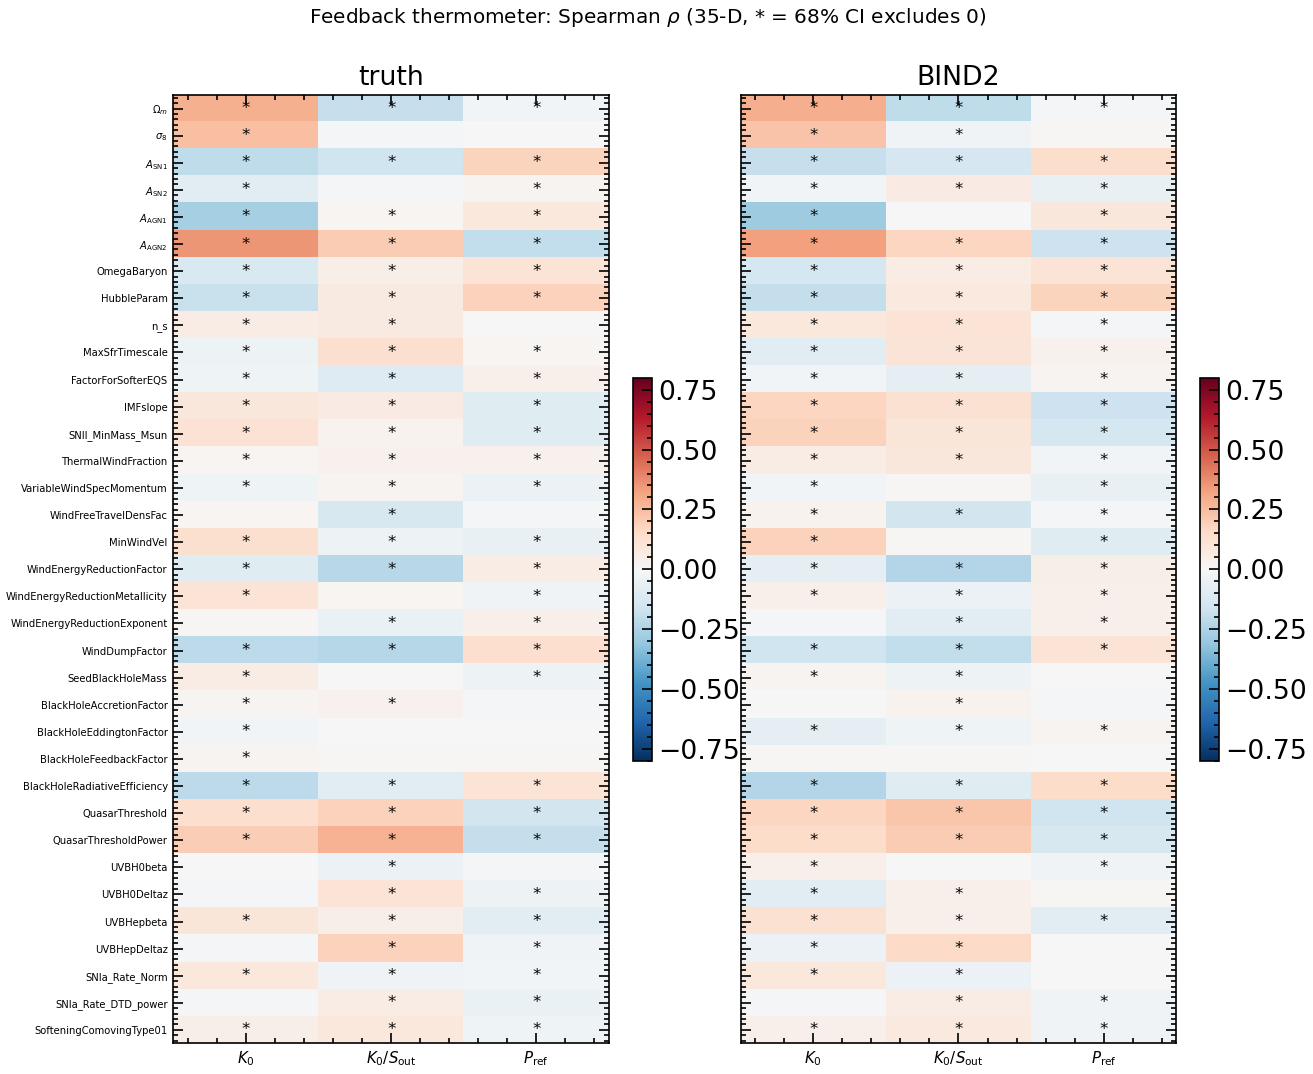

In [8]:
def fig_e4_thermometer(tbl=None, save=True):
    """35-D Spearman heatmap of (K0, Sratio, Pnorm) vs each parameter, truth vs BIND.
    Cells whose 68% CI excludes 0 are marked with a star."""
    if tbl is None:
        tbl = sb_tbl
    metrics = [('K0', r'$K_0$'), ('Sratio', r'$K_0/S_{\rm out}$'), ('Pnorm', r'$P_{\rm ref}$')]
    M  = {w: np.full((N_PARAMS, len(metrics)), np.nan) for w in ('truth', 'gen')}
    Ml = {w: np.full((N_PARAMS, len(metrics)), np.nan) for w in ('truth', 'gen')}
    Mh = {w: np.full((N_PARAMS, len(metrics)), np.nan) for w in ('truth', 'gen')}
    for ci, (mk, _) in enumerate(metrics):
        for w in ('truth', 'gen'):
            y = tbl[f'{w}_{mk}'].to_numpy()
            for j in range(1, N_PARAMS + 1):
                pv = tbl[f'p{j}'].to_numpy()
                if np.nanstd(pv) == 0:
                    continue
                r, lo, hi = spearman_boot(pv, y)
                M[w][j - 1, ci], Ml[w][j - 1, ci], Mh[w][j - 1, ci] = r, lo, hi

    fig, axes = plt.subplots(1, 2, figsize=(11, 9), sharey=True)
    for k, (w, ttl) in enumerate((('truth', 'truth'), ('gen', 'BIND2'))):
        ax = axes[k]
        im = ax.imshow(M[w], vmin=-0.8, vmax=0.8, cmap='RdBu_r', aspect='auto')
        ax.set_xticks(range(len(metrics)))
        ax.set_xticklabels([m[1] for m in metrics], fontsize=9)
        ax.set_yticks(range(N_PARAMS))
        ax.set_yticklabels([PARAM_LABELS[j] for j in range(1, N_PARAMS + 1)], fontsize=6)
        ax.set_title(f'{ttl}')
        # mark cells where 68% CI excludes 0
        for ji in range(N_PARAMS):
            for ci in range(len(metrics)):
                r, lo, hi = M[w][ji, ci], Ml[w][ji, ci], Mh[w][ji, ci]
                if np.isfinite(r) and (lo > 0 or hi < 0):
                    ax.text(ci, ji, '*', ha='center', va='center', fontsize=10, color='k')
        fig.colorbar(im, ax=ax, fraction=0.04)
    fig.suptitle(r'Feedback thermometer: Spearman $\rho$ (35-D, * = 68% CI excludes 0)',
                 y=1.00)
    fig.tight_layout()
    if save:
        save_fig(fig, 'figE4_thermometer')
    # Print top drivers per metric for truth
    for ci, (mk, _) in enumerate(metrics):
        order = np.argsort(-np.abs(M['truth'][:, ci]))
        print(f'\nTop drivers of {mk} (truth):')
        for idx in order[:3]:
            j = idx + 1
            print(f'   p{j:2d} {PARAM_LABELS[j]:14s} rho = {fmt_ci(M["truth"][idx, ci], Ml["truth"][idx, ci], Mh["truth"][idx, ci], ".2f")}')
    return fig, M, Ml, Mh


fig, E4_M, E4_Ml, E4_Mh = fig_e4_thermometer()
plt.show()


## 6. Figure E5 — Clean 1P sequences

Central entropy $K_0$ vs each feedback knob along the 1P one-parameter
sequences — the cleanest view of how a single feedback process heats (or fails
to heat) the core. Truth vs BIND.

  wrote icm_entropy_pressure_figs/figE5_1p_sequences.pdf
  wrote icm_entropy_pressure_figs/figE5_1p_sequences.png


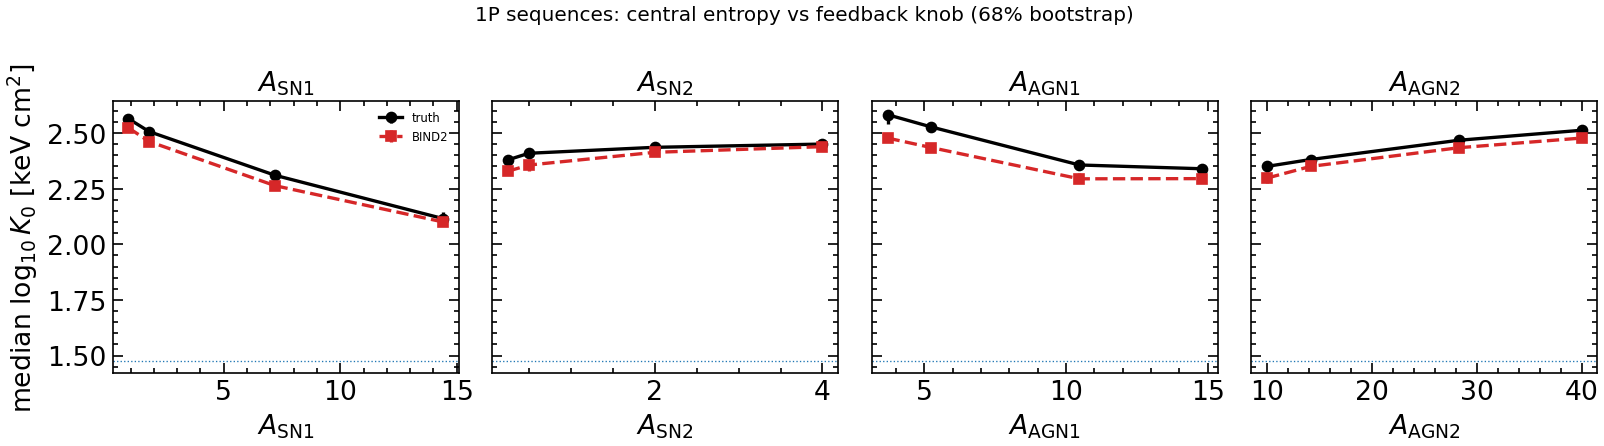

In [9]:
def fig_e5_1p(params=None, save=True):
    """1P central-entropy K0 vs each feedback knob with bootstrap 68% error bars."""
    if params is None:
        params = FEEDBACK_PARAMS
    fig, axes = plt.subplots(1, len(params), figsize=(3.4 * len(params), 3.7), sharey=True)
    for c, j in enumerate(params):
        ax = axes[c]
        sub = oneP_tbl[oneP_tbl['sim_id'].str.match(rf'1P_p{j}_')] if oneP_tbl['sim_id'].str.match(rf'1P_p{j}_').any() else oneP_tbl
        rows_t = []
        rows_g = []
        for pv, ss in sub.groupby(f'p{j}'):
            kt = ss['truth_K0'].to_numpy(); kg = ss['gen_K0'].to_numpy()
            kt = np.log10(kt[kt > 0]); kg = np.log10(kg[kg > 0])
            if kt.size < 4 or kg.size < 4:
                continue
            mt, lo_t, hi_t = bootstrap_ci(kt, np.nanmedian)
            mg, lo_g, hi_g = bootstrap_ci(kg, np.nanmedian)
            rows_t.append((pv, mt, lo_t, hi_t)); rows_g.append((pv, mg, lo_g, hi_g))
        if not rows_t:
            ax.set_title(f'{PARAM_LABELS[j]} (no data)'); continue
        rt = np.array(rows_t); rg = np.array(rows_g)
        ax.errorbar(rt[:, 0], rt[:, 1], yerr=[rt[:, 1] - rt[:, 2], rt[:, 3] - rt[:, 1]],
                    fmt='o-', color='k',       label='truth')
        ax.errorbar(rg[:, 0], rg[:, 1], yerr=[rg[:, 1] - rg[:, 2], rg[:, 3] - rg[:, 1]],
                    fmt='s--', color='tab:red', label='BIND2')
        ax.axhline(np.log10(ICM_LIT['K0_cool_core_thresh']), color='tab:blue', lw=0.8, ls=':')
        ax.set_xlabel(PARAM_LABELS[j])
        if c == 0:
            ax.set_ylabel(r'median $\log_{10} K_0$ [keV cm$^2$]'); ax.legend(fontsize=7)
        ax.set_title(PARAM_LABELS[j])
    fig.suptitle('1P sequences: central entropy vs feedback knob (68% bootstrap)', y=1.02)
    fig.tight_layout()
    if save:
        save_fig(fig, 'figE5_1p_sequences')
    return fig


fig = fig_e5_1p()
plt.show()


## 7. Figure E6 — MONEY PLOT: per-sim $\langle K_0\rangle$ vs $A_{\rm AGN,1}$, plus fidelity

Per simulation we collapse the $K_0$ population to its median; then fit
$\log_{10}\langle K_0\rangle = \alpha\,A_{\rm AGN1} + \beta$ with
`linmix_lite` (slope, intercept, $\sigma_{\rm int}$, bootstrap 68% CIs), for
truth and for BIND. We also overlay the literature cool-core threshold from
ACCEPT/Cavagnolo+09 to ground the *y*-axis. The right panels keep the original
fidelity diagnostics (per-halo BIND-vs-truth scatter for $K_0$ and $P_{\rm ref}$).


  wrote icm_entropy_pressure_figs/figE6_money_and_fidelity.pdf
  wrote icm_entropy_pressure_figs/figE6_money_and_fidelity.png
Truth d(log10 K0)/d(A_AGN1) slope = -0.014 [-0.020,-0.008]
BIND  d(log10 K0)/d(A_AGN1) slope = -0.014 [-0.019,-0.009]


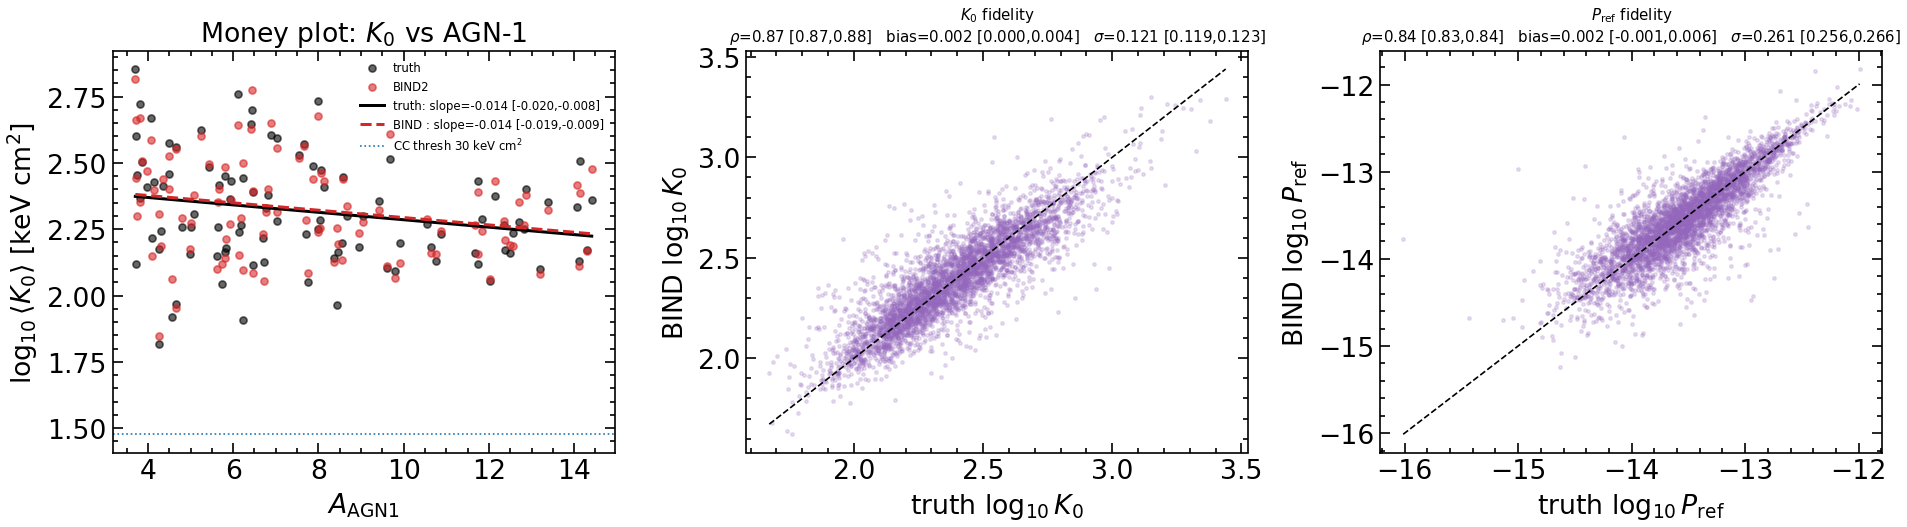

In [10]:
def fig_e6_money_and_fidelity(tbl=None, save=True):
    """Money plot: per-sim median K0 vs A_AGN1 with linmix_lite (truth vs BIND).
    Plus fidelity panels for K0 and P_ref."""
    if tbl is None:
        tbl = sb_tbl

    # per-sim collapse
    rows = []
    for sid, sub in tbl.groupby('sim_id'):
        kt = sub['truth_K0'].to_numpy(); kg = sub['gen_K0'].to_numpy()
        kt = kt[kt > 0]; kg = kg[kg > 0]
        if kt.size < 4 or kg.size < 4:
            continue
        rows.append({
            'sim_id': sid,
            'logK0_t': float(np.log10(np.nanmedian(kt))),
            'logK0_g': float(np.log10(np.nanmedian(kg))),
            'p5':       float(sub['p5'].iloc[0]),
        })
    per_sim = pd.DataFrame(rows)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

    # (a) Money plot — K0 vs A_AGN1
    ax = axes[0]
    f_t = linmix_lite(per_sim['p5'].to_numpy(), per_sim['logK0_t'].to_numpy())
    f_g = linmix_lite(per_sim['p5'].to_numpy(), per_sim['logK0_g'].to_numpy())
    ax.scatter(per_sim['p5'], per_sim['logK0_t'], s=18, c='k',       alpha=0.6, label='truth')
    ax.scatter(per_sim['p5'], per_sim['logK0_g'], s=18, c='tab:red', alpha=0.6, label='BIND2')
    xs = np.linspace(per_sim['p5'].min(), per_sim['p5'].max(), 30)
    ax.plot(xs, f_t['slope'] * xs + f_t['intercept'], 'k-',  lw=1.8,
            label=f'truth: slope={fmt_ci(f_t["slope"], f_t["slope_lo"], f_t["slope_hi"])}')
    ax.plot(xs, f_g['slope'] * xs + f_g['intercept'], color='tab:red', ls='--', lw=1.8,
            label=f'BIND : slope={fmt_ci(f_g["slope"], f_g["slope_lo"], f_g["slope_hi"])}')
    ax.axhline(np.log10(ICM_LIT['K0_cool_core_thresh']), color='tab:blue', ls=':', lw=1.0,
               label=f'CC thresh {ICM_LIT["K0_cool_core_thresh"]:.0f} keV cm$^2$')
    ax.set_xlabel(PARAM_LABELS[5]); ax.set_ylabel(r'$\log_{10}\langle K_0\rangle$ [keV cm$^2$]')
    ax.set_title(r'Money plot: $K_0$ vs AGN-1')
    ax.legend(fontsize=7)

    # (b) Per-halo K0 BIND vs truth
    ax = axes[1]
    t = tbl['truth_K0'].to_numpy(); g = tbl['gen_K0'].to_numpy()
    ok = (t > 0) & (g > 0) & np.isfinite(t) & np.isfinite(g)
    ax.scatter(np.log10(t[ok]), np.log10(g[ok]), s=4, c='tab:purple', alpha=0.2)
    lim = [np.nanmin(np.log10(t[ok])), np.nanmax(np.log10(t[ok]))]
    ax.plot(lim, lim, 'k--', lw=1)
    rho, lo, hi = spearman_boot(np.log10(t[ok]), np.log10(g[ok]))
    d = np.log10(g[ok]) - np.log10(t[ok])
    bias, blo, bhi = bootstrap_ci(d, np.nanmedian)
    scat, slo, shi = bootstrap_ci(d, np.nanstd)
    ax.set_xlabel(r'truth $\log_{10} K_0$'); ax.set_ylabel(r'BIND $\log_{10} K_0$')
    ax.set_title(f'$K_0$ fidelity\n$\\rho$={fmt_ci(rho, lo, hi, ".2f")}   bias={fmt_ci(bias, blo, bhi)}   $\\sigma$={fmt_ci(scat, slo, shi)}',
                 fontsize=9)

    # (c) Per-halo P_ref BIND vs truth
    ax = axes[2]
    t = tbl['truth_Pnorm'].to_numpy(); g = tbl['gen_Pnorm'].to_numpy()
    ok = (t > 0) & (g > 0) & np.isfinite(t) & np.isfinite(g)
    ax.scatter(np.log10(t[ok]), np.log10(g[ok]), s=4, c='tab:purple', alpha=0.2)
    lim = [np.nanmin(np.log10(t[ok])), np.nanmax(np.log10(t[ok]))]
    ax.plot(lim, lim, 'k--', lw=1)
    rho_p, lo_p, hi_p = spearman_boot(np.log10(t[ok]), np.log10(g[ok]))
    d = np.log10(g[ok]) - np.log10(t[ok])
    bias_p, blo_p, bhi_p = bootstrap_ci(d, np.nanmedian)
    scat_p, slo_p, shi_p = bootstrap_ci(d, np.nanstd)
    ax.set_xlabel(r'truth $\log_{10} P_{\rm ref}$'); ax.set_ylabel(r'BIND $\log_{10} P_{\rm ref}$')
    ax.set_title(f'$P_{{\\rm ref}}$ fidelity\n$\\rho$={fmt_ci(rho_p, lo_p, hi_p, ".2f")}   bias={fmt_ci(bias_p, blo_p, bhi_p)}   $\\sigma$={fmt_ci(scat_p, slo_p, shi_p)}',
                 fontsize=9)

    fig.tight_layout()
    if save:
        save_fig(fig, 'figE6_money_and_fidelity')

    out = {
        'truth_K0_AGN_slope':     f_t['slope'],
        'truth_K0_AGN_slope_lo':  f_t['slope_lo'],
        'truth_K0_AGN_slope_hi':  f_t['slope_hi'],
        'truth_K0_AGN_intercept': f_t['intercept'],
        'truth_K0_AGN_sigma_int': f_t['sigma_int'],
        'gen_K0_AGN_slope':       f_g['slope'],
        'gen_K0_AGN_slope_lo':    f_g['slope_lo'],
        'gen_K0_AGN_slope_hi':    f_g['slope_hi'],
        'K0_fidelity_rho': (rho, lo, hi),
        'K0_fidelity_bias': (bias, blo, bhi),
        'K0_fidelity_sigma': (scat, slo, shi),
        'P_fidelity_rho': (rho_p, lo_p, hi_p),
        'P_fidelity_bias': (bias_p, blo_p, bhi_p),
        'P_fidelity_sigma': (scat_p, slo_p, shi_p),
    }
    print(f'Truth d(log10 K0)/d(A_AGN1) slope = {fmt_ci(f_t["slope"], f_t["slope_lo"], f_t["slope_hi"])}')
    print(f'BIND  d(log10 K0)/d(A_AGN1) slope = {fmt_ci(f_g["slope"], f_g["slope_lo"], f_g["slope_hi"])}')
    return fig, out


fig, E6_OUT = fig_e6_money_and_fidelity()
plt.show()


## 8. Scorecard

In [11]:
def ep_scorecard(tbl=None):
    if tbl is None:
        tbl = sb_tbl
    print('=' * 72)
    print('ICM entropy/pressure feedback thermometer scorecard (bootstrap 68% CI)')
    print('=' * 72)

    # [1] CV null floor
    print('\n[1] CV null floor & emulator noise')
    for mk in ('K0', 'Pnorm'):
        if mk in CV_NULL:
            s = CV_NULL[mk]
            print(f'    {mk:6s}  sigma_CV={s["sigma_cv"]:.3f}  sigma_SB={s["sigma_sb35"]:.3f}  '
                  f'sigma_fb={s["sigma_fb"]:.3f}  ({100*(1 - s["frac_cv_floor"]):.0f}% feedback)')
            print(f'           BIND emu floor sigma={s["sigma_emu"]:.3f} dex, bias={s["bias_emu"]:+.3f}')

    # [2] Fidelity per halo
    print('\n[2] Per-halo fidelity (BIND vs truth)')
    print(f'    K0    rho   = {fmt_ci(*E6_OUT["K0_fidelity_rho"], ".2f")}'
          f'   bias = {fmt_ci(*E6_OUT["K0_fidelity_bias"])}'
          f'   sigma = {fmt_ci(*E6_OUT["K0_fidelity_sigma"])}')
    print(f'    P_ref rho   = {fmt_ci(*E6_OUT["P_fidelity_rho"], ".2f")}'
          f'   bias = {fmt_ci(*E6_OUT["P_fidelity_bias"])}'
          f'   sigma = {fmt_ci(*E6_OUT["P_fidelity_sigma"])}')

    # [3] Money plot summary
    print('\n[3] Money plot — central entropy vs AGN-1')
    print(f'    truth d(log K0)/d(A_AGN1) = {fmt_ci(E6_OUT["truth_K0_AGN_slope"], E6_OUT["truth_K0_AGN_slope_lo"], E6_OUT["truth_K0_AGN_slope_hi"])}')
    print(f'    BIND  d(log K0)/d(A_AGN1) = {fmt_ci(E6_OUT["gen_K0_AGN_slope"],   E6_OUT["gen_K0_AGN_slope_lo"],   E6_OUT["gen_K0_AGN_slope_hi"])}')

    # [4] Cool-core fractions
    if 'E2_CCF' in globals() and len(E2_CCF):
        mt, lo, hi = bootstrap_ci(E2_CCF['ccf_t'].to_numpy(), np.nanmean)
        mg, glo, ghi = bootstrap_ci(E2_CCF['ccf_g'].to_numpy(), np.nanmean)
        print('\n[4] Cool-core fraction (K0 < {:.0f} keV cm^2 per sim)'.format(ICM_LIT['K0_cool_core_thresh']))
        print(f'    truth <f_CC> = {fmt_ci(mt, lo, hi)}   BIND <f_CC> = {fmt_ci(mg, glo, ghi)}')

    # [5] Top driver in thermometer
    if 'E4_M' in globals():
        for ci, mk in enumerate(['K0', 'Sratio', 'Pnorm']):
            order = np.argsort(-np.abs(E4_M['truth'][:, ci]))
            print(f'\n[5.{ci+1}] Top truth-driver for {mk}')
            for idx in order[:3]:
                j = idx + 1
                print(f'      p{j:2d} {PARAM_LABELS[j]:14s} rho = {fmt_ci(E4_M["truth"][idx, ci], E4_Ml["truth"][idx, ci], E4_Mh["truth"][idx, ci], ".2f")}')

    print('\n[6] Literature anchors:')
    print(f'    Cool-core K0 threshold (ACCEPT) : {ICM_LIT["K0_cool_core_thresh"]:.0f} keV cm^2')
    print(f'    NCC typical K0                  : {ICM_LIT["K0_NCC_typical"]:.0f} keV cm^2')
    print(f'    Arnaud+10 UPP P0                : {ICM_LIT["UPP_P0"]:.3f}')
    print('=' * 72)


ep_scorecard()


ICM entropy/pressure feedback thermometer scorecard (bootstrap 68% CI)

[1] CV null floor & emulator noise
    K0      sigma_CV=0.116  sigma_SB=0.247  sigma_fb=0.218  (78% feedback)
           BIND emu floor sigma=0.086 dex, bias=-0.043
    Pnorm   sigma_CV=0.464  sigma_SB=0.461  sigma_fb=0.000  (-1% feedback)
           BIND emu floor sigma=0.204 dex, bias=+0.073

[2] Per-halo fidelity (BIND vs truth)
    K0    rho   = 0.87 [0.87,0.88]   bias = 0.002 [0.000,0.004]   sigma = 0.121 [0.119,0.123]
    P_ref rho   = 0.84 [0.83,0.84]   bias = 0.002 [-0.001,0.006]   sigma = 0.261 [0.256,0.266]

[3] Money plot — central entropy vs AGN-1
    truth d(log K0)/d(A_AGN1) = -0.014 [-0.020,-0.008]
    BIND  d(log K0)/d(A_AGN1) = -0.014 [-0.019,-0.009]

[4] Cool-core fraction (K0 < 30 keV cm^2 per sim)
    truth <f_CC> = 0.000 [0.000,0.000]   BIND <f_CC> = 0.000 [0.000,0.000]

[5.1] Top truth-driver for K0
      p 6 $A_{\rm AGN2}$ rho = 0.35 [0.34,0.37]
      p 1 $\Omega_m$     rho = 0.28 [0.27,0.29]